In [3]:
from pytools.vtk_io import readVTK
import matplotlib.pyplot as plt
import numpy as np

PRS
RHO
VX1
VX2
forceSGx
forceSGy
toomre
vk


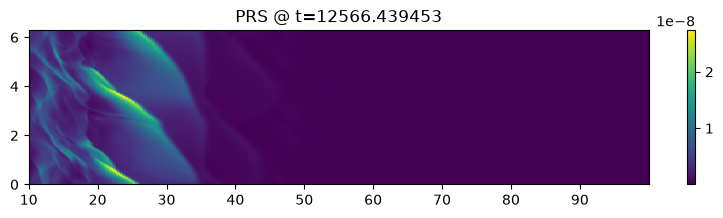

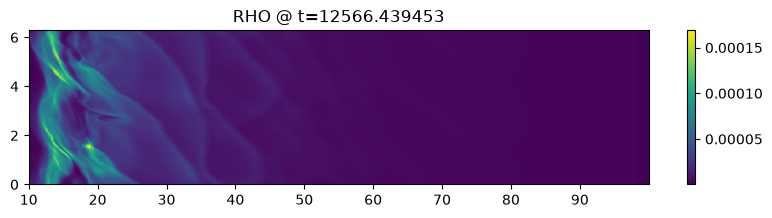

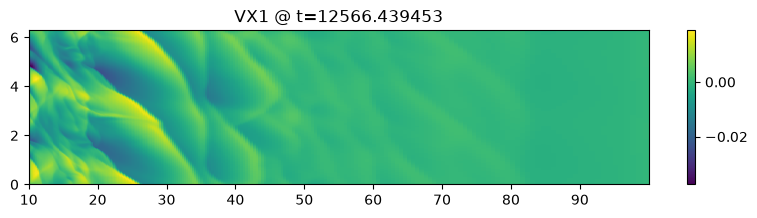

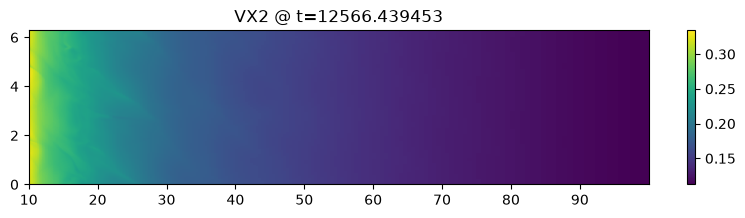

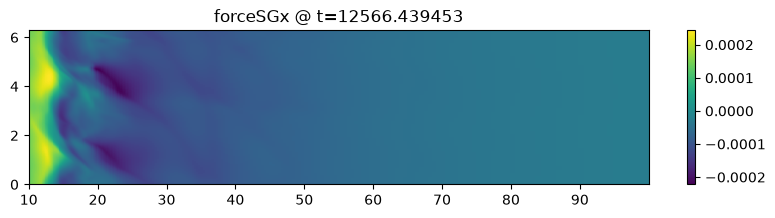

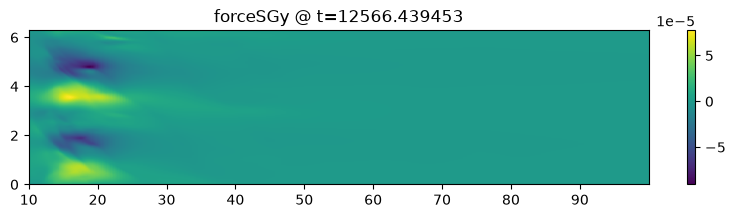

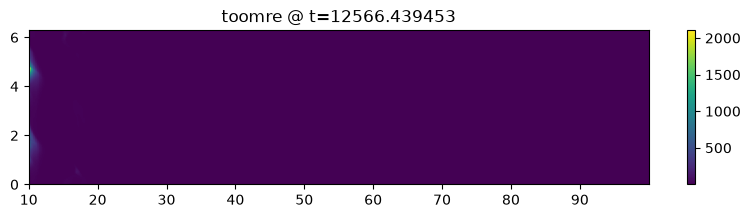

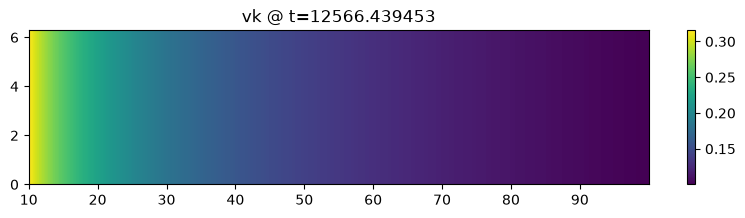

In [249]:
# Load the last VTK file produced by Idefix
V=readVTK("data.0100.vtk")

# Display all fields"
for field in V.data.keys():
  print(field)
  plt.figure(figsize=(10,2))
  #plt.xlim(0,3)
  #f= plt.figure()

  plt.pcolormesh(V.x,V.y,V.data[field][:,:,0].T)
  plt.title(field+ " @ t=%f"%V.t[0])
  plt.colorbar()
  #plt.gca().set_aspect('equal')

[1.8196096]


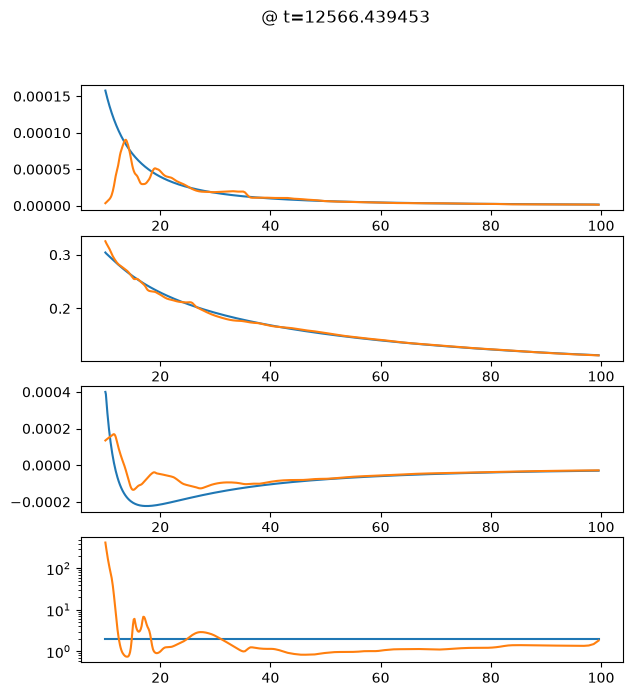

In [250]:
V0=readVTK("data.0000.vtk")
V=readVTK("data.0100.vtk")

rho_mean = np.mean(V.data['RHO'], axis=(1))
toomre_mean = np.mean(V.data['toomre'], axis=(1))

print(toomre_mean[-1])

r = V0.x

fig, ax      = plt.subplots(4,1, figsize=(7,7.5))

fig.suptitle(" @ t=%f"%V.t[0])

ax[0].plot(V0.x, V0.data['RHO'][:,0,0].T )
ax[1].plot(V0.x, V0.data['VX2'][:,0,0].T)

ax[2].plot(V0.x, V0.data['forceSGx'][:,0,0].T)
#ax[2].plot(V0.x, V0.data['vk'][:,0,0].T**2 /r)
#ax[2].plot(r, f_r_hure)

ax[3].plot(V0.x, V0.data['toomre'][:,0,0].T)

ax[0].plot(V.x, rho_mean)
ax[1].plot(V.x, V.data['VX2'][:,0,0].T)
ax[2].plot(V.x, V.data['forceSGx'][:,0,0].T)
ax[3].plot(V.x, toomre_mean)

ax[3].set_yscale('log')


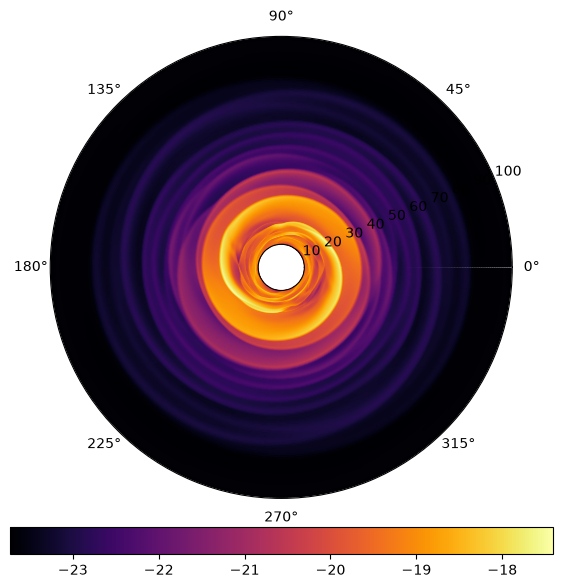

In [251]:
V=readVTK("data.0100.vtk")

fig, ax      = plt.subplots(figsize=(7,7.5), subplot_kw={'projection': 'polar'})

cs=ax.pcolormesh(V.y, V.x, np.log(V.data['PRS'][:,:,0]), cmap='inferno', shading='gouraud', alpha=1, snap=True)

fig.colorbar(cs, orientation='horizontal', pad=0.050)

# Ax
ax.set_rmin(10.0)
ax.set_rmax(100.0)
ax.set_rorigin(0.0)
ax.grid(False)

#fig.savefig('test_GI_idefix.png', dpi=1002, bbox_inches='tight')